In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import pickle
import librosa
import librosa.display
from IPython.display import Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras

In [2]:
import pandas as pd

df = pd.read_csv(r'D:\web\cnn_clasification\features.csv')
df.head()


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,anjing1.wav,4339712,0.319109,0.098094,0.150055,0.002703,1405.083905,6.119486e+05,1829.737758,2.676386e+05,...,89.46835,-7.776935,83.163330,-2.378656,95.28114,-8.379879,76.59403,-8.450209,84.014040,audioanjing
1,anjing13.wav,957502,0.268558,0.093145,0.127598,0.006447,1403.832459,2.563689e+06,1552.793594,8.831522e+05,...,75.62306,4.044745,115.895860,5.843103,199.38676,2.066340,163.62393,-1.496752,89.817560,audioanjing
2,anjing14.wav,986174,0.497179,0.086932,0.135725,0.008153,2830.790268,6.418756e+05,3412.212849,2.194590e+05,...,53.95971,2.538061,57.953910,-0.804857,50.78780,3.249757,50.29459,-1.818355,52.441967,audioanjing
3,anjing15.wav,904254,0.482412,0.098097,0.322554,0.014417,2326.863291,8.531006e+05,2894.370170,3.470806e+05,...,55.05463,2.645354,46.765625,1.461451,75.28942,-1.052646,54.34993,-7.756590,40.987904,audioanjing
4,anjing19.wav,693310,0.394611,0.106742,0.138870,0.011014,2098.515355,1.271919e+06,2264.233081,1.007944e+06,...,181.96715,-1.743313,74.005646,-2.875215,85.28679,-1.286174,115.24583,-3.146584,123.337364,audioanjing


In [3]:
df.shape

(272, 60)

In [4]:
df.dtypes

filename                    object
length                       int64
chroma_stft_mean           float64
chroma_stft_var            float64
rms_mean                   float64
rms_var                    float64
spectral_centroid_mean     float64
spectral_centroid_var      float64
spectral_bandwidth_mean    float64
spectral_bandwidth_var     float64
rolloff_mean               float64
rolloff_var                float64
zero_crossing_rate_mean    float64
zero_crossing_rate_var     float64
harmony_mean               float64
harmony_var                float64
perceptr_mean              float64
perceptr_var               float64
tempo                       object
mfcc1_mean                 float64
mfcc1_var                  float64
mfcc2_mean                 float64
mfcc2_var                  float64
mfcc3_mean                 float64
mfcc3_var                  float64
mfcc4_mean                 float64
mfcc4_var                  float64
mfcc5_mean                 float64
mfcc5_var           

In [5]:
df=df.drop(labels='filename',axis=1)

In [6]:
audio_recording=r"D:/web/cnn_clasification/archive/Data/genres_original/audiobabi/babi4.wav"
data , sr=librosa.load(audio_recording)
print(type(data),type(sr))


<class 'numpy.ndarray'> <class 'int'>


In [7]:
librosa.load(audio_recording, sr=45600)

(array([ 1.1964964e-06, -3.0796611e-05, -3.1943360e-05, ...,
         9.9991112e-06,  1.1191084e-05, -1.9876438e-06],
       shape=(892658,), dtype=float32),
 45600)

C:\Users\acer\AppData\Local\Temp\ipykernel_6320\2260726204.py:4: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(stft,sr=sr,x_axis='time',y_axis='hz')


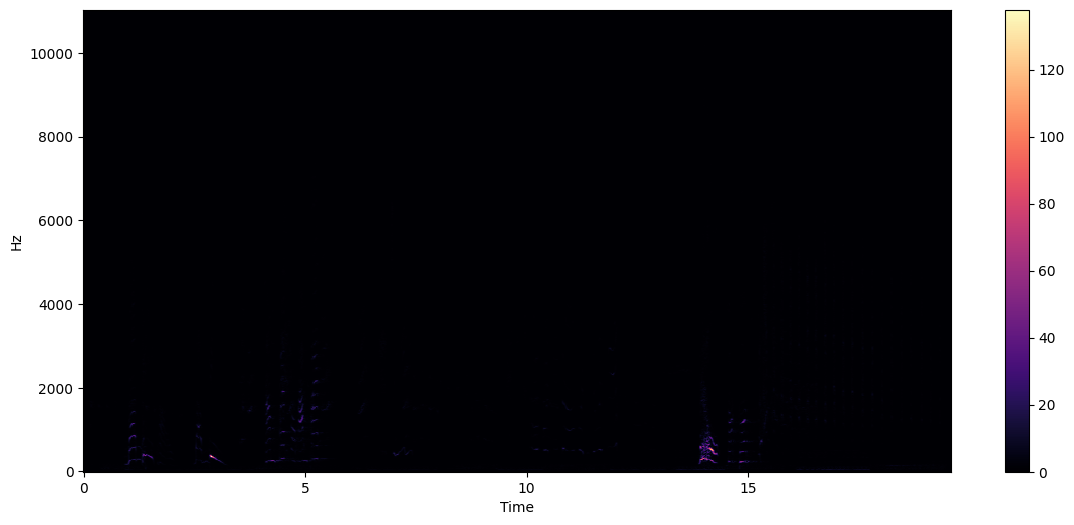

In [8]:
stft =librosa.stft(data)
stft_db =librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(14,6))
librosa.display.specshow(stft,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()

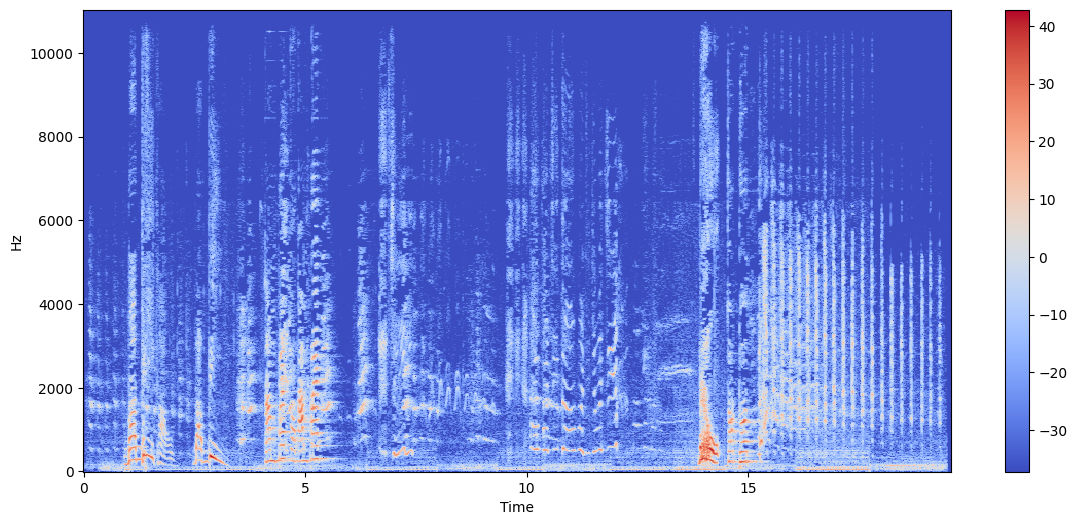

In [9]:
stft=librosa.stft(data)
stft_db=librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(14,6))
librosa.display.specshow(stft_db,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()

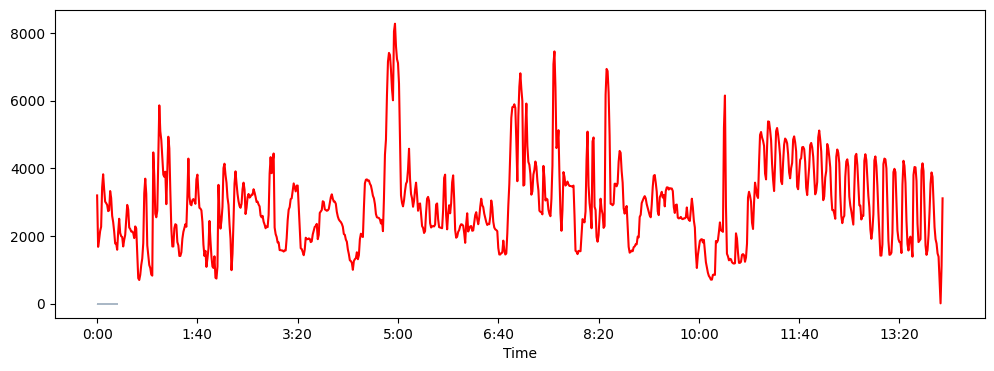

In [10]:
spectral_rolloff = librosa.feature.spectral_rolloff(y=data+0.01, sr=sr)[0]

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
librosa.display.waveshow(data, sr=sr, alpha=0.4, color="#2B4F72")
plt.plot(spectral_rolloff, color='r')
plt.show()


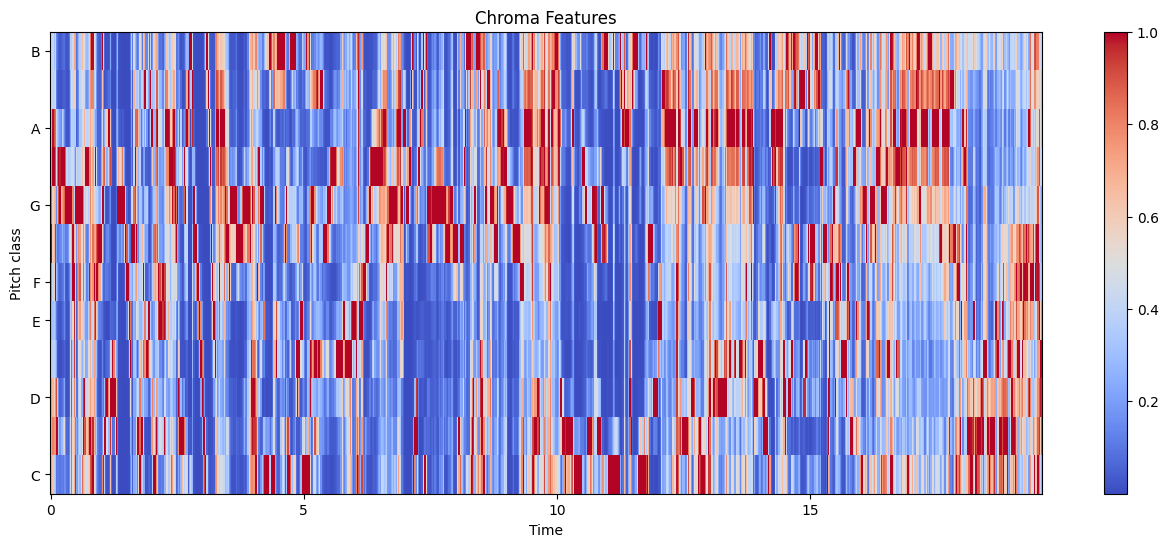

In [11]:
import librosa.display as lplt
import matplotlib.pyplot as plt

chroma = librosa.feature.chroma_stft(y=data, sr=sr)

plt.figure(figsize=(16, 6))
lplt.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar()
plt.title("Chroma Features")
plt.show()


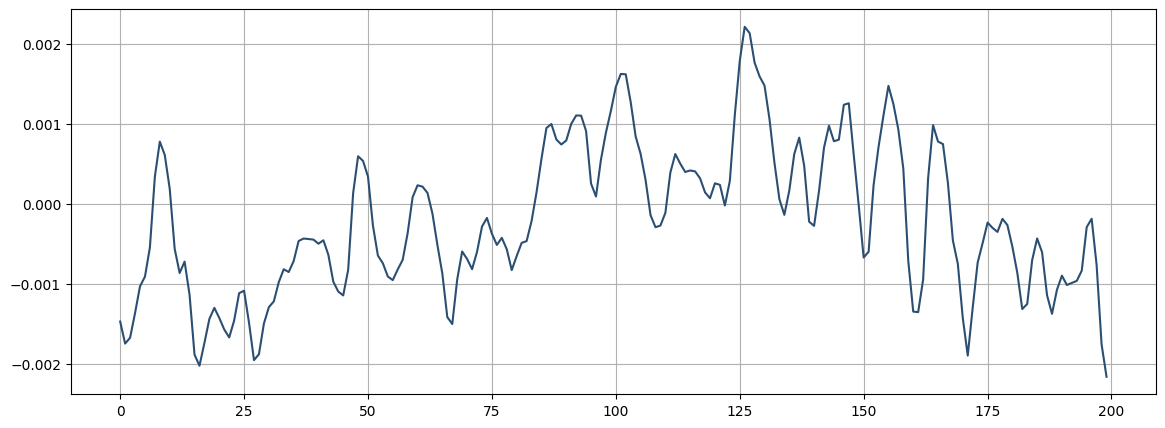

In [12]:
start=1000
end=1200
plt.figure(figsize=(14,5))
plt.plot(data[start:end],color="#2B4F72")
plt.grid()

In [13]:
zero_cross_rate=librosa.zero_crossings(data[start:end],pad=False)
print("The number of zero-crossings is:",sum(zero_cross_rate))

The number of zero-crossings is: 20


In [14]:
class_list=df.iloc[:,-1]
convertor = LabelEncoder()

In [15]:
y=convertor.fit_transform(class_list)

In [16]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7])

In [17]:
print(df.iloc[:,:-1])

      length  chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0    4339712          0.319109         0.098094  0.150055  0.002703   
1     957502          0.268558         0.093145  0.127598  0.006447   
2     986174          0.497179         0.086932  0.135725  0.008153   
3     904254          0.482412         0.098097  0.322554  0.014417   
4     693310          0.394611         0.106742  0.138870  0.011014   
..       ...               ...              ...       ...       ...   
267  1020990          0.342846         0.107109  0.140297  0.004865   
268   351294          0.308825         0.105163  0.317827  0.031109   
269   334910          0.359401         0.096568  0.138406  0.010301   
270  1430590          0.388956         0.105758  0.175578  0.019999   
271   640062          0.381071         0.100978  0.203602  0.009870   

     spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0               1405.083905           6.119486e+05              1829

In [18]:
import ast

def clean_value(val):
    """Convert string like '[123.4]' or '123.4' to float"""
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return float(parsed[0])
            return float(parsed)
        except:
            return np.nan
    return val

# Terapkan ke semua kolom kecuali label (kolom terakhir)
for col in df.columns[:-1]:
    df[col] = df[col].apply(clean_value)

# Drop baris yang error (jika ada)
df = df.dropna()


In [19]:
from sklearn.preprocessing import StandardScaler
fit=StandardScaler()
X=fit.fit_transform(np.array(df.iloc[:,:-1],dtype=float))

In [20]:
X_train ,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33)

In [21]:
len(y_train)

182

In [22]:
len(y_test)

90

In [23]:
from keras.models import Sequential

In [24]:
def trainModel(model,epochs,optimizer):
    batch_size =128
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics='accuracy'
    )
    return model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=epochs,batch_size=batch_size)

In [25]:
def plotValidate(history):
    print("Validation Accuracy",max(history.history["val_accuracy"]))
    pd.Dataframe(history.history).plot(figsize=(12,6))
    plt.show()

In [26]:
import keras as k

In [27]:
# jika belum ada alias k:
from tensorflow import keras as k

# === Model ===
model = k.Sequential([
    k.layers.Input(shape=(X_train.shape[1],)),        # hindari warning input_shape
    k.layers.Dense(512, activation='relu'),
    k.layers.Dropout(0.2),
    k.layers.Dense(256, activation='relu'),
    k.layers.Dropout(0.2),
    k.layers.Dense(128, activation='relu'),
    k.layers.Dropout(0.2),
    k.layers.Dense(64, activation='relu'),
    k.layers.Dropout(0.2),
    k.layers.Dense(10, activation='softmax'),
])

model.summary()

# === Trainer ===
def trainModel(model, epochs=100, optimizer='adam', batch_size=128,
               loss='sparse_categorical_crossentropy'):
    """
    Gunakan loss berikut sesuai tipe y:
      - 'sparse_categorical_crossentropy'  -> y_train berupa integer class id (0..9)
      - 'categorical_crossentropy'         -> y_train one-hot vector
    """
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=['accuracy'])     # <- harus list, bukan string

    # (opsional) callback biar training stabil
    callbacks = [
        k.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        k.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]

    return model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

# === Train ===
model_history = trainModel(model=model, epochs=100, optimizer='adam')


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │          30,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 203,338 (794.29 KB)

 Trainable params: 203,338 (794.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 638ms/step - accuracy: 0.2253 - loss: 2.2331 - val_accuracy: 0.3556 - val_loss: 2.1031 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.2967 - loss: 2.1125 - val_accuracy: 0.3556 - val_loss: 2.0203 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3242 - loss: 2.0036 - val_accuracy: 0.3667 - val_loss: 1.9790 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.3242 - loss: 1.9251 - val_accuracy: 0.3333 - val_loss: 1.9416 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.3462 - loss: 1.8448 - val_accuracy: 0.3556 - val_loss: 1.9199 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.3462 - loss: 1.8045 - val_accuracy: 0.3778 - val_loss: 1.9093 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.3846 - loss: 1.7488 - val_acc

Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5938 - loss: 1.2203 — val_f1: 0.1895
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step - accuracy: 0.5495 - loss: 1.3217 - val_accuracy: 0.4000 - val_loss: 1.8908
Epoch 2/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5781 - loss: 1.2830 — val_f1: 0.1895
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.5879 - loss: 1.3102 - val_accuracy: 0.4000 - val_loss: 1.8919
Epoch 3/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5156 - loss: 1.3777 — val_f1: 0.1895
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5495 - loss: 1.3241 - val_accuracy: 0.4000 - val_loss: 1.8926
Epoch 4/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5469 - loss: 1.3441 — val_f1: 0.1895
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5659 - loss: 1.3190 - val_accuracy: 0.4000 - val_loss: 1.8937
Epoch 5/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5156 - loss: 1.3390 — val_f1: 0.1895
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/s

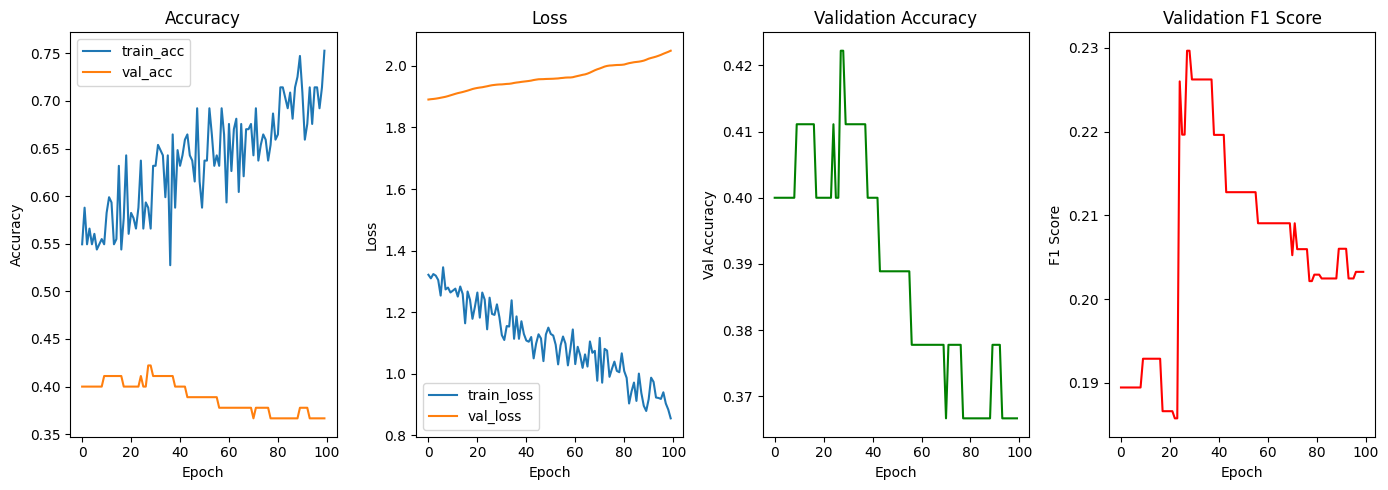

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score
import tensorflow as tf

# === Callback untuk F1 Score ===
class F1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.f1_scores = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        f1 = f1_score(self.y_val, y_pred, average='macro')
        self.f1_scores.append(f1)
        print(f" — val_f1: {f1:.4f}")

# === Training dengan callback F1 ===
f1_callback = F1Callback(X_test, y_test)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, batch_size=128,
    callbacks=[f1_callback],
    verbose=1
)

# === Plot Accuracy, Loss, Val Accuracy, dan F1 ===
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,4,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,4,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Validation Accuracy
plt.subplot(1,4,3)
plt.plot(history.history['val_accuracy'], color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')

# F1 Score
plt.subplot(1,4,4)
plt.plot(f1_callback.f1_scores, color='red')
plt.title('Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


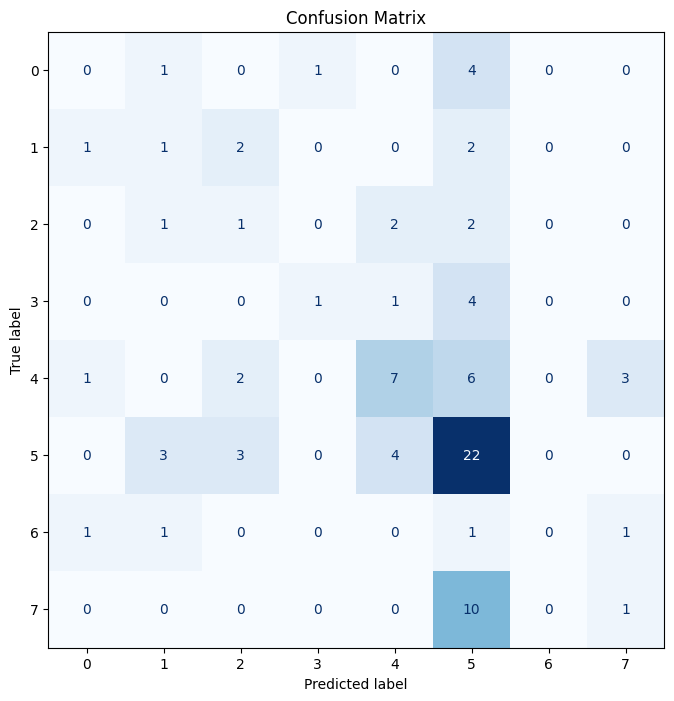

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === Prediksi pada data test ===
y_pred = np.argmax(model.predict(X_test), axis=1)   # ambil kelas prediksi
y_true = y_test                                     # label asli (pastikan integer class)

# === Confusion Matrix ===
cm = confusion_matrix(y_true, y_pred)

# === Visualisasi ===
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()
